# Dataset structure

## 1. Features explanation

- **id** - Unique numerical identifier for the movie in the Filmweb database.
- **title** - The Polish title of the movie as it appears on the site.
- **originalTitle** - The title in its original language of production.
- **url** - Direct link to the movie’s profile page on Filmweb.pl.
- **poster_url** - Direct link to the image file of the movie's official poster.
- **year** - The official release or production year.
- **duration** - Total runtime of the movie in minutes.
- **genres** - Categories/genres assigned to the film
- **production_country** - Country or countries where the film was produced.
- **directors** - List of directors.
- **creators** - List of creators
- **desc_short** - A brief tagline or short synopsis of the movie.
- **desc_long** - The comprehensive, detailed plot summary.
- **worldReleaseDate** - The date of the very first screening anywhere in the world (often festivals).
- **worldPublicReleaseDate** - The date the movie was released to the general public worldwide.
- **releaseDatePoland** - The official premiere date in Polish cinemas.
- **vod** - Information regarding the film's availability on streaming/Video On Demand platforms.
- **rate** - The average user rating on a scale of 1 to 10.
- **rate_count** - The total number of users who have submitted a rating.
- **critic_rate** - The average score based on professional film critics' reviews.
- **critic_count** - The total number of professional reviews recorded.
- **countWantToSee** - The number of users who have added the movie to their "Want to see" list.
- **budget** - The estimated cost of producing the film (usually in USD).
- **boxoffice_in_usa** - Total gross revenue earned from theaters in the United States.
- **boxoffice_outside_usa** - Total gross revenue earned from international markets (excluding the USA).
- **boxoffice_world** - Total worldwide gross revenue (the sum of USA and international earnings).

## 2. load data

In [1]:
import pandas as pd
df = pd.read_csv("films_dataset.csv")

In [2]:
print(f"Rekords: {df.shape[0]}")

Rekords: 701103


## 3. Missing Value Heatmap

In [3]:
df.isna().sum()

id                             0
title                     617957
originalTitle                  1
url                         1336
poster_url                475230
year                           0
duration                  213554
genres                     67486
production_country         38729
directors                 276598
creators                  371763
desc_short                624707
desc_long                 613212
worldReleaseDate          305781
worldPublicReleaseDate    340943
releaseDatePoland         687971
vod                       667008
rate                      293361
rate_count                293361
critic_rate               662474
critic_count              662474
countWantToSee            293361
budget                    694809
boxoffice_in_usa          690063
boxoffice_outside_usa     691168
boxoffice_world           691165
dtype: int64

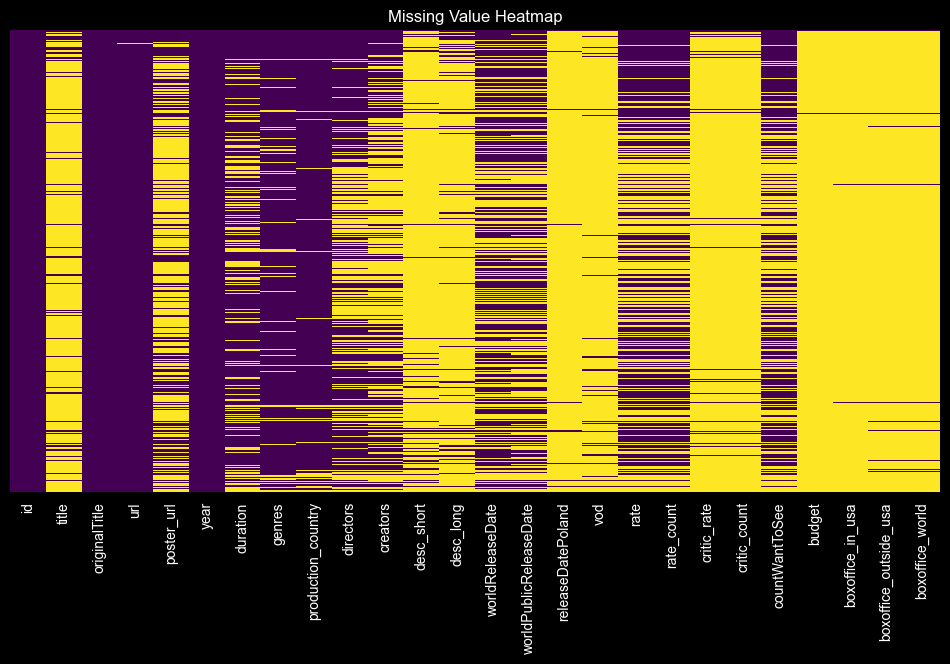

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Missing Value Heatmap')
plt.show()

The chart illustrates significant missing values within the dataset. However, this is due to the varying popularity of films and the sheer scale of the data.

## 4. Numerical preview

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,701103.0,1.443691e+06,2.897764e+06,1.0,316433.50,514682.0,734322.50,1.011916e+07
year,701103.0,1.987464e+03,3.371039e+01,1888.0,1970.00,2002.0,2012.00,2.035000e+03
duration,487549.0,6.187640e+01,1.089333e+02,0.0,17.00,72.0,93.00,5.142000e+04
worldReleaseDate,395322.0,1.986005e+07,3.638371e+05,0.0,19640506.00,20031213.0,20121101.00,2.031122e+07
worldPublicReleaseDate,360160.0,1.983555e+07,3.697990e+05,0.0,19590313.00,20020108.0,20110623.00,2.031122e+07
releaseDatePoland,13132.0,2.008944e+07,1.944147e+05,18000101.0,20040416.00,20140811.0,20211126.00,2.029122e+07
rate,407742.0,4.008238e+00,3.101347e+00,0.0,0.00,5.0,6.50,1.000000e+01
rate_count,407742.0,9.975605e+02,1.243721e+04,0.0,0.00,2.0,14.00,1.048255e+06
critic_rate,38629.0,5.783776e+00,1.675568e+00,0.0,5.00,6.0,7.00,1.000000e+01
critic_count,38629.0,6.452173e+00,1.130350e+01,0.0,1.00,2.0,6.00,9.800000e+01


Most of the data points show expected values; however, with such a large dataset, certain anomalies are to be expected—such as the minimum value for "countWantToSee" being -188, which is logically impossible.

## 5. Categorical Data Analysis

In [6]:
def display_unique_cat_vals(series, label, max_list_len=250):
    unique_values = (
        series
        .str.split(',')
        .explode()
        .str.strip()
        .unique()
    )

    print(f"{label}: {len(unique_values)}\n")

    print_end = ", ..." if len(unique_values) > max_list_len else "\n"
    print("Unique values: \n", ", ".join(unique_values[:max_list_len].astype(str)), print_end)

## Genres

In [7]:
display_unique_cat_vals(df["genres"], "Genres")

Genres: 61

Unique values: 
 Thriller, Akcja, Melodramat, Wojenny, Komedia, Musical, Biograficzny, Dramat, Muzyczny, Obyczajowy, Familijny, Przygodowy, Animacja, Horror, Sensacyjny, Sci-Fi, Psychologiczny, Katastroficzny, Dramat historyczny, Komedia kryminalna, Dramat obyczajowy, Romans, Czarna komedia, Kostiumowy, Dla dzieci, Kryminał, Gangsterski, Komedia rom., Sportowy, Fantasy, Dokumentalny, Satyra, Baśń, Komedia obycz., Historyczny, Świąteczny, Krótkometrażowy, Przyrodniczy, Religijny, Dla młodzieży, Erotyczny, Biblijny, Surrealistyczny, Western, Anime, Polityczny, Dokumentalizowany, Poetycki, Niemy, Film-Noir, Dramat sądowy, Animacja dla dorosłych, Dreszczowiec, nan, Fabularyzowany dok., Propagandowy, Szpiegowski, Groteska filmowa, Sztuki walki, XXX, True crime 



## Production countries

In [8]:
display_unique_cat_vals(df["production_country"], "Production countries")

Production countries: 216

Unique values: 
 US, FR, JP, DE, GB, AU, BE, NL, IE, PL, HU, DK, SE, IT, MX, ES, CH, AT, IN, NZ, IS, NO, CA, AR, CZ, SK, HK, GR, XFY, CN, BR, PE, AW, MA, MC, RU, LU, RO, KE, CU, XWG, IL, KR, XCS, IR, MK, TR, ZA, MT, PT, BG, LI, TN, UA, XSU, GE, FO, UZ, TJ, NP, HR, VE, SG, TW, FI, XYU, ZW, XEG, PH, CY, nan, CI, NA, CO, ID, BY, TH, SI, AL, EG, KZ, EC, PA, MY, HT, VN, CL, PR, MD, JO, UY, BW, BA, KG, GH, BT, DZ, MZ, TT, BO, JM, XSM, LT, ML, LB, LY, KW, SA, DO, SN, AE, EE, AZ, LV, AM, XPI, MN, MR, TD, AO, BB, AF, SY, KP, TM, PK, KH, BS, ZM, MG, NI, CR, NE, CG, GT, VA, CM, TZ, EH, LK, NG, BF, GA, RW, XZR, MQ, GN, GW, IQ, BJ, CD, ET, BD, PY, RS, XSI, GL, SR, AD, SV, CV, XVN, FJ, PG, ER, DJ, SO, LA, HN, MU, YE, SC, TG, SD, XBU, BH, BZ, AG, LS, GP, XKO, GY, BI, CF, TO, UG, OM, LR, SL, NU, MO, QA, ME, VC, XKV, MW, SZ, DM, GD, KM, WS, SM, MV, GM, FM, PW, KI, LC, MH, TV, GQ, VU, BN, PS, MM, KN 



## Directors

In [9]:
display_unique_cat_vals(df["directors"], "Directors")

Directors: 156764

Unique values: 
 Kevin Reynolds, Kevin Hooks, Anthony Minghella, John Landis, Scott Hicks, Jeroen Krabbé, Michael Winterbottom, Jim Sheridan, Don Bluth, Gary Goldman, János Szász, Stephen Norrington, Wolfgang Petersen, Bille August, Robert Duvall, Paul Thomas Anderson, George Miller, Michael Bay, Steven Spielberg, Taylor Hackford, Joel Coen, Gus Van Sant, Agnieszka Holland, Neil Jordan, Woody Allen, Radosław Piwowarski, Mike van Diem, Terrence Malick, Quentin Tarantino, Allison Anders, Robert Harling, Wayne Wang, James Mangold, Randall Wallace, Irwin Winkler, Steven Soderbergh, Duncan McLachlan, F. Gary Gray, Jan Kounen, Władysław Pasikowski, Robert Rodriguez, John Lasseter, Andrew Stanton, Pedro Almodóvar, Fred Gerber, Trish McAdam, John McNaughton, Mimi Leder, Steve Rash, Andy Tennant, Barry Levinson, Michał Rosa, Jon Avnet, Les Mayfield, Claude Chabrol, Michael Haneke, Ridley Scott, Paul W.S. Anderson, Marcin Ziębiński, Peter Medak, Peter Berg, Brett Ratner, Rolan

## Creators

In [10]:
display_unique_cat_vals(df["creators"], "Creators")

Creators: 187589

Unique values: 
 Scott Yagemann, William Mickelberry, Dan Vining, Anthony Minghella, Dan Aykroyd, John Landis, Jan Sardi, Edwin de Vries, Frank Cottrell Boyce, Jim Sheridan, Terry George, Susan Gauthier, Noni White, János Szász, András Szeredás, David S. Goyer, Andrew W. Marlowe, Ann Biderman, Robert Duvall, Paul Thomas Anderson, Judy Morris, George Miller, Tony Gilroy, J.J. Abrams, David Franzoni, Jonathan Lemkin, Ethan Coen, Joel Coen, Matt Damon, Ben Affleck, Christopher Hampton, Neil Jordan, Pat McCabe, Woody Allen, Radosław Piwowarski, Ruud van Megen, Laurens Geels, Terrence Malick, Allison Anders, Quentin Tarantino, Robert Harling, Larry Gross, Jean-Claude Carrière, James Mangold, Randall Wallace, Oliver Sacks, Steve Levitt, Scott Frank, Bayard Johnson, Matthew Horton, Kate Lanier, Takashi Bufford, Joël Houssin, Władysław Pasikowski, Robert Rodriguez, Don McEnery, Andrew Stanton, Ray Loriga, Pedro Almodóvar, Paul Bernbaum, Trish McAdam, Stephen Peters, Michael T

## Vod options

In [11]:
display_unique_cat_vals(df["vod"], "Vod options")

Vod options: 28

Unique values: 
 CDA.pl, nan, Apple TV+, Player, Prime Video, Canal+, Gonet.tv, Megogo, WP Pilot, Disney+, Rakuten TV, Play Now, SkyShowtime, Netflix, TVP VOD, HBO Max, TV Smart, Nowe Horyzonty, Filmbox+, 35mm.online, Flixclassic, Polsat Box Go, Pięć Smaków, Katoflix, Red GO, MojeeKino.pl, E-Kino Pod Baranami, Ninateka 

